## Business Context

Shaha Finlease is an NBFC (Non-Banking Financial Company) managing a portfolio of **9,000 Non-Performing Loan (NPL) accounts** with **₹143 Cr in outstanding debt**. Recovery operations currently rely on manual channel assignment (Call / Field / Legal), with no data-driven segmentation or prioritisation in place.

**Objective:** Analyse the portfolio to identify recovery drivers, segment borrowers into actionable groups, detect inefficiencies in channel assignment, and recommend a data-backed recovery strategy — including a 3-use-case AI roadmap.

---

## Dataset

| Column | Description |
|---|---|
| `account_id` | Unique borrower identifier |
| `loan_amount` | Original loan sanctioned |
| `outstanding_amount` | Current unpaid balance |
| `days_past_due` | Days since last payment |
| `customer_location` | Tier 1 / Tier 2 / Tier 3 city |
| `income_band` | Low / Medium / High |
| `payment_history` | Good / Average / Poor |
| `contact_attempts` | Total agent contact attempts |
| `last_channel` | Last channel used (Call/Field/Legal) |
| `last_outcome` | Paid / Promised / No Response / Refused |
| `assigned_channel` | Current assignment for next contact |
| `recovery_amount` | Amount recovered so far |

---

## Analysis Structure

1. Setup & Data Loading  
2. Exploratory Data Analysis (EDA)  
3. Identifying Recovery Drivers  
4. Borrower Segmentation (5-tier model)  
5. Channel Mismatch Detection  
6. Rule-Based Scoring Model (0–100)  
7. Impact Estimation  
8. AI Roadmap (3 use cases)  

---
## 1. Setup & Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
sns.set_style('whitegrid')

In [7]:
df = pd.read_csv('C:/Users/Saarim/Desktop/Projects/shaha_finlease_recovery_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

Dataset shape: (9000, 12)

Column dtypes:
account_id            object
loan_amount            int64
outstanding_amount     int64
days_past_due          int64
customer_location     object
income_band           object
payment_history       object
contact_attempts       int64
last_channel          object
last_outcome          object
assigned_channel      object
recovery_amount        int64
dtype: object

Missing values: 0
Duplicate rows: 0


In [8]:
df.head()

,account_id,loan_amount,outstanding_amount,days_past_due,customer_location,income_band,payment_history,contact_attempts,last_channel,last_outcome,assigned_channel,recovery_amount
0,SFL100000,88113,70212,206,Tier 1,Low,Average,4,Call,Promised,Legal,0
1,SFL100001,37696,19902,133,Tier 2,Low,Average,1,Legal,Paid,Field,16316
2,SFL100002,22601,17449,446,Tier 3,Low,Average,2,Call,Refused,Call,0
3,SFL100003,34867,16766,697,Tier 3,Low,Good,2,Legal,Refused,Legal,0
4,SFL100004,69935,51102,243,Tier 2,Medium,Average,10,Field,Promised,Field,0


In [9]:
df.describe()

,loan_amount,outstanding_amount,days_past_due,contact_attempts,recovery_amount
count,9.000000e+03,9.000000e+03,9000.000000,9000.000000,9.000000e+03
mean,2.505767e+05,1.588952e+05,228.331111,7.081778,2.817954e+04
std,3.008146e+05,2.047988e+05,206.036617,4.715672,8.348280e+04
min,1.000800e+04,3.152000e+03,1.000000,1.000000,0.000000e+00
25%,4.686400e+04,2.688150e+04,86.000000,4.000000,0.000000e+00
50%,1.186805e+05,6.735850e+04,161.000000,6.000000,0.000000e+00
75%,3.107508e+05,2.001768e+05,303.000000,9.000000,1.118100e+04
max,1.199394e+06,1.115862e+06,900.000000,20.000000,1.079422e+06


---
## 2. Exploratory Data Analysis (EDA)

Before jumping into segmentation, we first establish the baseline — overall recovery rate, distribution of key variables, and how the portfolio is currently structured. This shapes all downstream analysis.

In [10]:
total_outstanding = df['outstanding_amount'].sum()
total_recovered = df['recovery_amount'].sum()
recovery_pct = total_recovered / total_outstanding * 100
zero_recovery_pct = (df['recovery_amount'] == 0).mean() * 100

print('=' * 60)
print('  PORTFOLIO SUMMARY')
print('=' * 60)
print(f"  Total Accounts        :  {len(df):,}")
print(f"  Total Outstanding     :  ₹{total_outstanding/1e7:.2f} Cr")
print(f"  Total Recovered       :  ₹{total_recovered/1e7:.2f} Cr")
print(f"  Overall Recovery %    :  {recovery_pct:.2f}%")
print(f"  Accounts with ZERO Rec:  {zero_recovery_pct:.1f}%")
print('=' * 60)

  PORTFOLIO SUMMARY
  Total Accounts        :  9,000
  Total Outstanding     :  ₹143.01 Cr
  Total Recovered       :  ₹25.36 Cr
  Overall Recovery %    :  17.73%
  Accounts with ZERO Rec:  68.1%


**Observation:** Only 17.73% of ₹143 Cr has been recovered, and 68.1% of accounts have zero recovery at all. This signals a triage and prioritisation problem — not every account needs the same effort or channel.

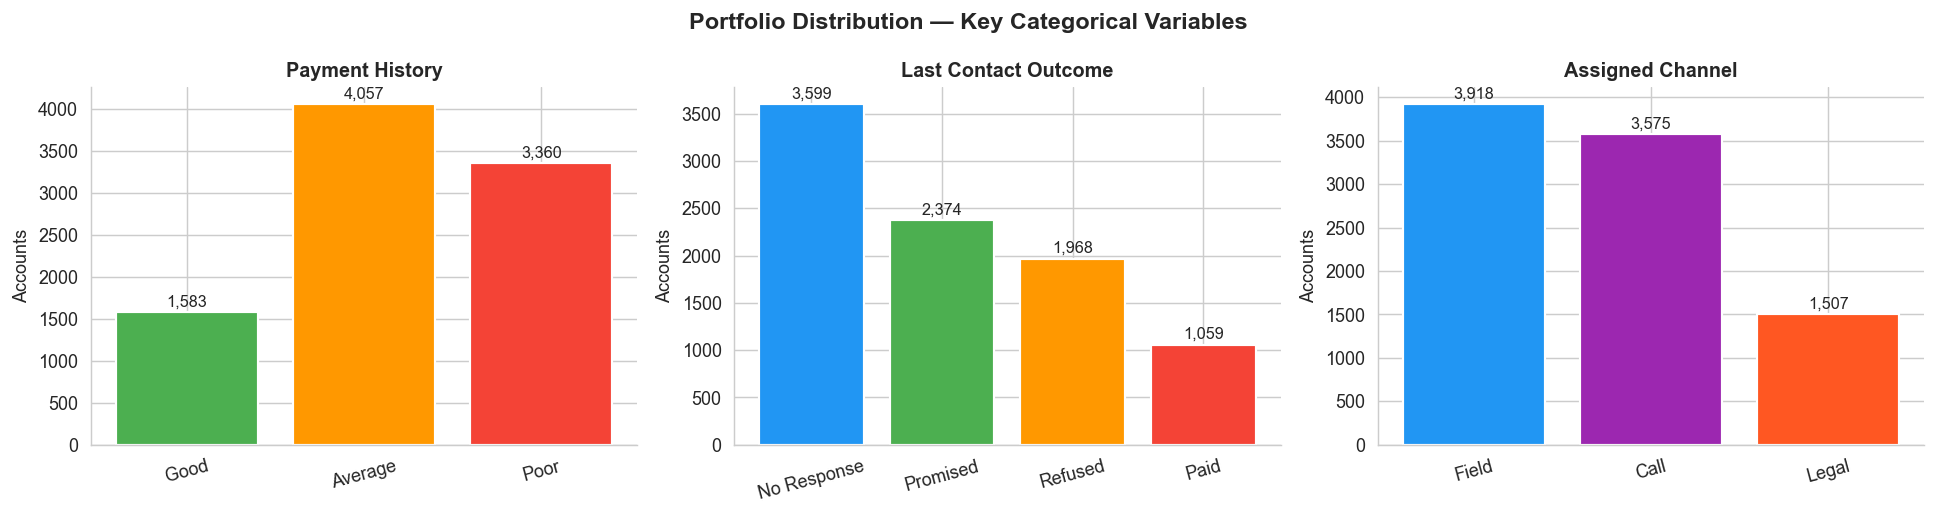

In [11]:
# Distribution of categorical variables
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Portfolio Distribution — Key Categorical Variables', fontsize=13, fontweight='bold')

cats = [
    ('payment_history', 'Payment History', ['Good', 'Average', 'Poor'], ['#4CAF50', '#FF9800', '#F44336']),
    ('last_outcome', 'Last Contact Outcome', None, COLORS),
    ('assigned_channel', 'Assigned Channel', None, ['#2196F3', '#9C27B0', '#FF5722'])
]

for ax, (col, title, order, colors) in zip(axes, cats):
    data = df[col].value_counts()
    if order:
        data = data.reindex([o for o in order if o in data.index])
    bars = ax.bar(data.index, data.values, color=colors[:len(data)], edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Accounts')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=15)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

---
## 3. Identifying Recovery Drivers

We now test which variables correlate most strongly with recovery. The goal is to find signals that can drive the scoring model weights in Section 6.

In [12]:
# --- Driver 1: Payment History ---
grp_ph = df.groupby('payment_history').agg(
    accounts=('account_id', 'count'),
    outstanding=('outstanding_amount', 'sum'),
    recovered=('recovery_amount', 'sum')
)
grp_ph['recovery_pct'] = (grp_ph['recovered'] / grp_ph['outstanding'] * 100).round(2)
grp_ph['outstanding_cr'] = (grp_ph['outstanding'] / 1e7).round(2)
grp_ph = grp_ph.reindex(['Good', 'Average', 'Poor'])

print("Recovery % by Payment History:")
print(grp_ph[['accounts', 'outstanding_cr', 'recovery_pct']].to_string())

good_pct = grp_ph.loc['Good', 'recovery_pct']
poor_pct = grp_ph.loc['Poor', 'recovery_pct']
print(f"\nKEY INSIGHT: Good payers recover at {good_pct}% vs Poor at {poor_pct}% — a {good_pct/poor_pct:.0f}x gap.")
print("Payment history is the single strongest predictor in this dataset.")

Recovery % by Payment History:
                 accounts  outstanding_cr  recovery_pct
payment_history                                        
Good                 1583           25.71         40.11
Average              4057           65.84         19.27
Poor                 3360           51.46          4.58

KEY INSIGHT: Good payers recover at 40.11% vs Poor at 4.58% — a 9x gap.
Payment history is the single strongest predictor in this dataset.


In [13]:
# --- Driver 2: Last Contact Outcome ---
grp_lo = df.groupby('last_outcome').agg(
    accounts=('account_id', 'count'),
    outstanding=('outstanding_amount', 'sum'),
    recovered=('recovery_amount', 'sum')
)
grp_lo['recovery_pct'] = (grp_lo['recovered'] / grp_lo['outstanding'] * 100).round(2)
grp_lo = grp_lo.reindex(['Paid', 'Promised', 'No Response', 'Refused'])

print("Recovery % by Last Outcome:")
print(grp_lo[['accounts', 'recovery_pct']].to_string())

Recovery % by Last Outcome:
              accounts  recovery_pct
last_outcome                        
Paid              1059         35.03
Promised          2374         25.31
No Response       3599         13.02
Refused           1968          6.46


In [14]:
# --- Driver 3: Days Past Due (Debt Age) ---
df['dpd_bucket'] = pd.cut(
    df['days_past_due'],
    bins=[0, 90, 180, 365, 730, 9999],
    labels=['0-90', '91-180', '181-365', '366-730', '730+']
)

grp_dpd = df.groupby('dpd_bucket', observed=True).agg(
    accounts=('account_id', 'count'),
    outstanding=('outstanding_amount', 'sum'),
    recovered=('recovery_amount', 'sum')
)
grp_dpd['recovery_pct'] = (grp_dpd['recovered'] / grp_dpd['outstanding'] * 100).round(2)

print("Recovery % by Days Past Due:")
print(grp_dpd[['accounts', 'recovery_pct']].to_string())
print(f"\nRecovery drops from {grp_dpd['recovery_pct'].iloc[0]}% (0-90 days) to {grp_dpd['recovery_pct'].iloc[-1]}% (730+ days).")
print("Early-stage accounts are nearly 3x more recoverable than very late-stage ones.")

Recovery % by Days Past Due:
            accounts  recovery_pct
dpd_bucket                        
0-90            2367         24.68
91-180          2698         18.56
181-365         2510         15.78
366-730          990          9.26
730+             435          8.95

Recovery drops from 24.68% (0-90 days) to 8.95% (730+ days).
Early-stage accounts are nearly 3x more recoverable than very late-stage ones.


In [15]:
# --- Driver 4: Contact Attempts (Diminishing Returns) ---
df['ca_bucket'] = pd.cut(
    df['contact_attempts'],
    bins=[0, 2, 5, 8, 12, 20],
    labels=['1-2', '3-5', '6-8', '9-12', '13+']
)

grp_ca = df.groupby('ca_bucket', observed=True).agg(
    accounts=('account_id', 'count'),
    outstanding=('outstanding_amount', 'sum'),
    recovered=('recovery_amount', 'sum')
)
grp_ca['recovery_pct'] = (grp_ca['recovered'] / grp_ca['outstanding'] * 100).round(2)

print("Recovery % by Contact Attempts:")
print(grp_ca[['accounts', 'recovery_pct']].to_string())
print("\nKEY INSIGHT: Recovery falls consistently after 5 contacts.")
print("Capping outreach at 5 attempts avoids wasted cost with minimal recovery sacrifice.")

Recovery % by Contact Attempts:
           accounts  recovery_pct
ca_bucket                        
1-2            1352         22.41
3-5            2681         18.64
6-8            2218         16.73
9-12           1481         16.60
13+            1268         13.95

KEY INSIGHT: Recovery falls consistently after 5 contacts.
Capping outreach at 5 attempts avoids wasted cost with minimal recovery sacrifice.


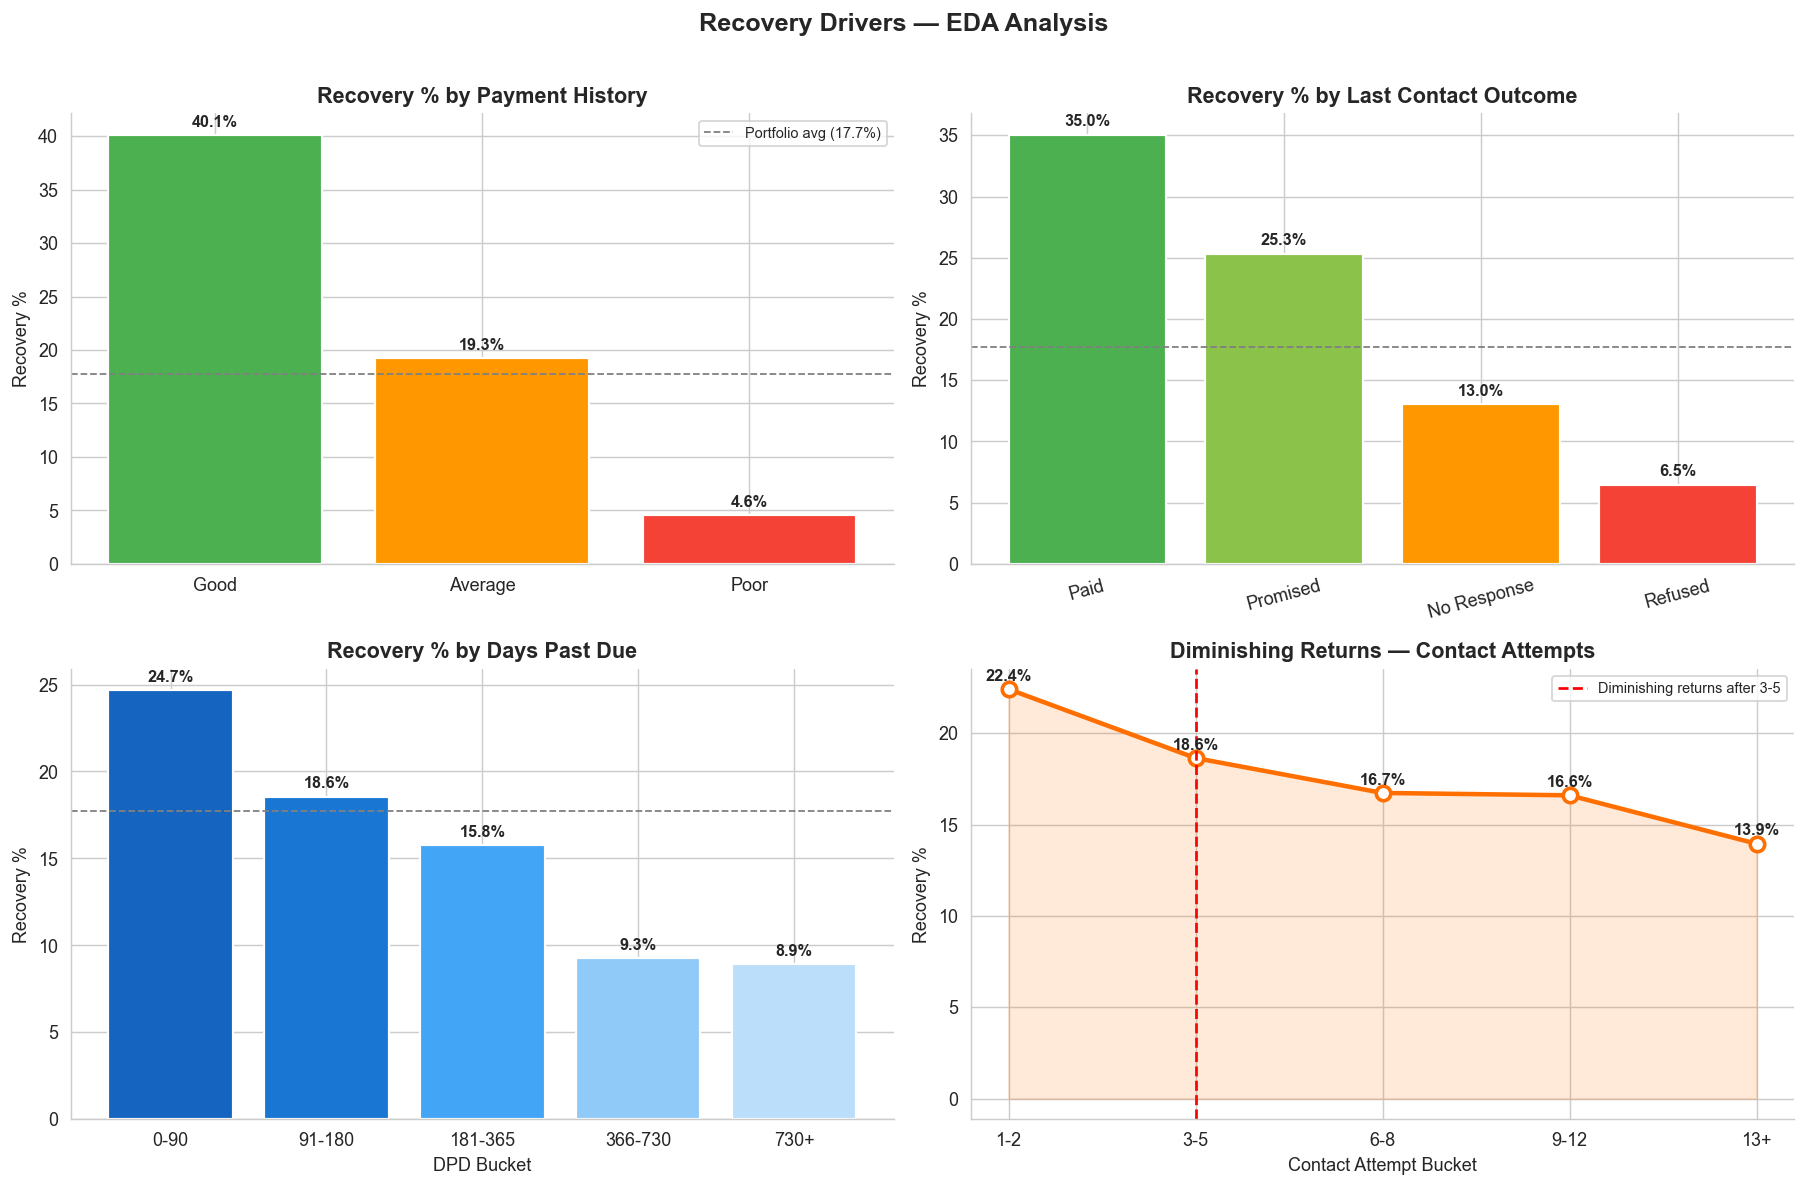

Chart saved: recovery_drivers.png


In [16]:
# --- Chart: All 4 Recovery Drivers Side by Side ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Recovery Drivers — EDA Analysis', fontsize=14, fontweight='bold', y=1.01)

# Chart 1: Payment History
ax1 = axes[0, 0]
bars = ax1.bar(grp_ph.index, grp_ph['recovery_pct'],
               color=['#4CAF50', '#FF9800', '#F44336'], edgecolor='white', linewidth=1.2)
ax1.set_title('Recovery % by Payment History', fontweight='bold')
ax1.set_ylabel('Recovery %')
ax1.axhline(recovery_pct, color='grey', linestyle='--', linewidth=1, label=f'Portfolio avg ({recovery_pct:.1f}%)')
ax1.legend(fontsize=8)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Chart 2: Last Outcome
ax2 = axes[0, 1]
outcome_order = ['Paid', 'Promised', 'No Response', 'Refused']
outcome_colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336']
bars2 = ax2.bar(grp_lo.reindex(outcome_order).index, grp_lo.reindex(outcome_order)['recovery_pct'],
                color=outcome_colors, edgecolor='white', linewidth=1.2)
ax2.set_title('Recovery % by Last Contact Outcome', fontweight='bold')
ax2.set_ylabel('Recovery %')
ax2.axhline(recovery_pct, color='grey', linestyle='--', linewidth=1)
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Chart 3: Days Past Due
ax3 = axes[1, 0]
dpd_colors = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9', '#BBDEFB']
bars3 = ax3.bar(grp_dpd.index.astype(str), grp_dpd['recovery_pct'],
                color=dpd_colors, edgecolor='white', linewidth=1.2)
ax3.set_title('Recovery % by Days Past Due', fontweight='bold')
ax3.set_ylabel('Recovery %')
ax3.set_xlabel('DPD Bucket')
ax3.axhline(recovery_pct, color='grey', linestyle='--', linewidth=1)
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# Chart 4: Contact Attempts (Diminishing Returns)
ax4 = axes[1, 1]
ca_vals = grp_ca['recovery_pct'].values
ca_labels = grp_ca.index.astype(str)
ax4.plot(ca_labels, ca_vals, marker='o', color='#FF6F00', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax4.fill_between(range(len(ca_labels)), ca_vals, alpha=0.15, color='#FF6F00')
ax4.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='Diminishing returns after 3-5')
ax4.set_title('Diminishing Returns — Contact Attempts', fontweight='bold')
ax4.set_ylabel('Recovery %')
ax4.set_xlabel('Contact Attempt Bucket')
ax4.set_xticks(range(len(ca_labels)))
ax4.set_xticklabels(ca_labels)
ax4.legend(fontsize=8)
for i, v in enumerate(ca_vals):
    ax4.text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('recovery_drivers.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart saved: recovery_drivers.png")

**Summary of Recovery Drivers:**

| Driver | Signal Strength | Key Finding |
|---|---|---|
| Payment History | ⭐⭐⭐⭐⭐ Strongest | Good vs Poor = **9x recovery gap** (40% vs 4.6%) |
| Last Outcome | ⭐⭐⭐⭐ Strong | Promised accounts recover at 25% — nearly 4x Refused |
| Days Past Due | ⭐⭐⭐ Moderate | Recovery decays from 24.7% → 9% as debt ages |
| Contact Attempts | ⭐⭐ Diminishing | Returns drop after 5 contacts — cap outreach to save cost |

These 4 drivers become the weights in the scoring model.

---
## 4. Borrower Segmentation (5-Tier Model)

Using a combination of the 3 strongest drivers — `payment_history`, `last_outcome`, and `days_past_due` — we segment the portfolio into 5 actionable tiers. Each tier gets a distinct recovery priority and recommended channel.

In [17]:
conditions = [
    # Segment 1: Quick Wins — willing borrowers, recent debt
    (df['payment_history'].isin(['Good', 'Average'])) &
    (df['last_outcome'].isin(['Paid', 'Promised'])) &
    (df['days_past_due'] <= 180),

    # Segment 2: High Potential — good history but not yet contacted effectively
    (df['payment_history'] == 'Good') &
    (df['last_outcome'].isin(['No Response', 'Refused'])),

    # Segment 3: Mid Tier — average history, mixed outcomes
    (df['payment_history'] == 'Average') &
    (df['last_outcome'].isin(['No Response', 'Refused'])),

    # Segment 4: High Risk — poor history, very late stage
    (df['payment_history'] == 'Poor') &
    (df['days_past_due'] > 365),
]

labels = ['Quick Win', 'High Potential', 'Mid Tier', 'High Risk']
df['segment'] = np.select(conditions, labels, default='Watch List')

seg = df.groupby('segment').agg(
    accounts=('account_id', 'count'),
    outstanding=('outstanding_amount', 'sum'),
    recovered=('recovery_amount', 'sum')
)
seg['recovery_pct'] = (seg['recovered'] / seg['outstanding'] * 100).round(2)
seg['outstanding_cr'] = (seg['outstanding'] / 1e7).round(2)
seg['avg_outstanding'] = (seg['outstanding'] / seg['accounts']).round(0)

order = ['Quick Win', 'High Potential', 'Mid Tier', 'Watch List', 'High Risk']
seg = seg.reindex(order)

print("Segment Distribution:")
print(seg[['accounts', 'outstanding_cr', 'recovery_pct', 'avg_outstanding']].to_string())

Segment Distribution:
                accounts  outstanding_cr  recovery_pct  avg_outstanding
segment                                                                
Quick Win           1495           24.25         41.37         162211.0
High Potential       608            9.56         21.45         157173.0
Mid Tier            2368           37.81         14.68         159662.0
Watch List          3961           61.93         12.14         156347.0
High Risk            568            9.46          2.23         166585.0


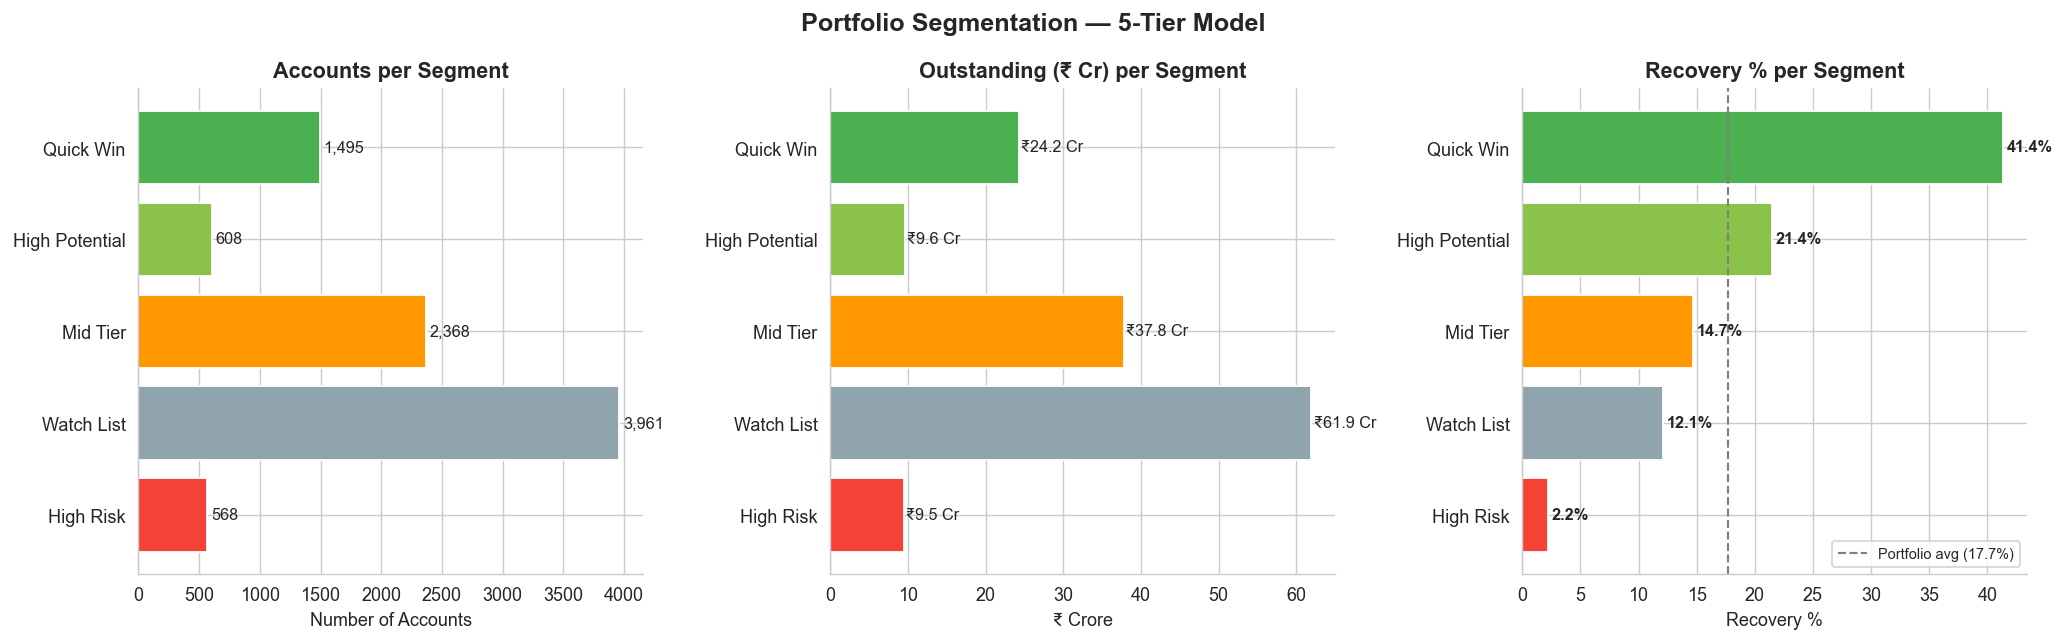

Chart saved: segmentation.png


In [18]:
# --- Segmentation Chart ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Portfolio Segmentation — 5-Tier Model', fontsize=14, fontweight='bold')

seg_colors = ['#4CAF50', '#8BC34A', '#FF9800', '#90A4AE', '#F44336']
order = ['Quick Win', 'High Potential', 'Mid Tier', 'Watch List', 'High Risk']
seg_ordered = seg.reindex(order)

# Accounts per segment
ax1 = axes[0]
bars = ax1.barh(order[::-1], seg_ordered['accounts'].values[::-1], color=seg_colors[::-1], edgecolor='white')
ax1.set_title('Accounts per Segment', fontweight='bold')
ax1.set_xlabel('Number of Accounts')
for bar in bars:
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Outstanding per segment
ax2 = axes[1]
bars2 = ax2.barh(order[::-1], seg_ordered['outstanding_cr'].values[::-1], color=seg_colors[::-1], edgecolor='white')
ax2.set_title('Outstanding (₹ Cr) per Segment', fontweight='bold')
ax2.set_xlabel('₹ Crore')
for bar in bars2:
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'₹{bar.get_width():.1f} Cr', va='center', fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Recovery % per segment
ax3 = axes[2]
bars3 = ax3.barh(order[::-1], seg_ordered['recovery_pct'].values[::-1], color=seg_colors[::-1], edgecolor='white')
ax3.axvline(recovery_pct, color='grey', linestyle='--', linewidth=1.2, label=f'Portfolio avg ({recovery_pct:.1f}%)')
ax3.set_title('Recovery % per Segment', fontweight='bold')
ax3.set_xlabel('Recovery %')
ax3.legend(fontsize=8)
for bar in bars3:
    ax3.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}%', va='center', fontsize=9, fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('segmentation.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart saved: segmentation.png")

**Segmentation Logic Summary:**

| Segment | Accounts | Outstanding | Recovery % | Priority | Recommended Channel |
|---|---|---|---|---|---|
| 🟢 Quick Win | 1,495 | ₹24.25 Cr | 41.37% | P1 — Immediate | Call |
| 🟡 High Potential | 608 | ₹9.56 Cr | 21.45% | P1 — Immediate | Field |
| 🟠 Mid Tier | 2,368 | ₹37.81 Cr | 14.68% | P2 — This Week | Call |
| 🔵 Watch List | 3,961 | ₹61.93 Cr | 12.14% | P3 — Monitor | Call |
| 🔴 High Risk | 568 | ₹9.46 Cr | 2.23% | P4 — Last Resort | Legal |

---
## 5. Channel Mismatch Detection

We assign each segment a recommended channel based on EDA-derived logic, then compare it against the currently `assigned_channel` in the data. Any discrepancy is a mismatch — meaning the company is spending the wrong resource on that account.

In [19]:
channel_map = {
    'Quick Win':      'Call',
    'High Potential': 'Field',
    'Mid Tier':       'Call',
    'Watch List':     'Call',
    'High Risk':      'Legal'
}
df['recommended_channel'] = df['segment'].map(channel_map)

mismatch = df[df['assigned_channel'] != df['recommended_channel']]
mismatch_pct = len(mismatch) / len(df) * 100
mismatch_cr = mismatch['outstanding_amount'].sum() / 1e7

print('=' * 60)
print('  CHANNEL MISMATCH ANALYSIS')
print('=' * 60)
print(f"  Mismatched accounts  :  {len(mismatch):,}  ({mismatch_pct:.1f}% of portfolio)")
print(f"  Mismatched outstanding:  ₹{mismatch_cr:.2f} Cr")
print('=' * 60)

crosstab = pd.crosstab(df['assigned_channel'], df['recommended_channel'])

# Key mismatches
field_to_call = crosstab.loc['Field', 'Call'] if 'Call' in crosstab.columns else 0
legal_to_call = crosstab.loc['Legal', 'Call'] if 'Call' in crosstab.columns else 0
print(f"\nKey Mismatches:")
print(f"  Field → Call  :  {field_to_call:,} accounts  (expensive field visits that only need a call)")
print(f"  Legal → Call  :  {legal_to_call:,} accounts  (costly legal action on recoverable borrowers)")

  CHANNEL MISMATCH ANALYSIS
  Mismatched accounts  :  5,173  (57.5% of portfolio)
  Mismatched outstanding:  ₹83.12 Cr

Key Mismatches:
  Field → Call  :  3,485 accounts  (expensive field visits that only need a call)
  Legal → Call  :  1,128 accounts  (costly legal action on recoverable borrowers)


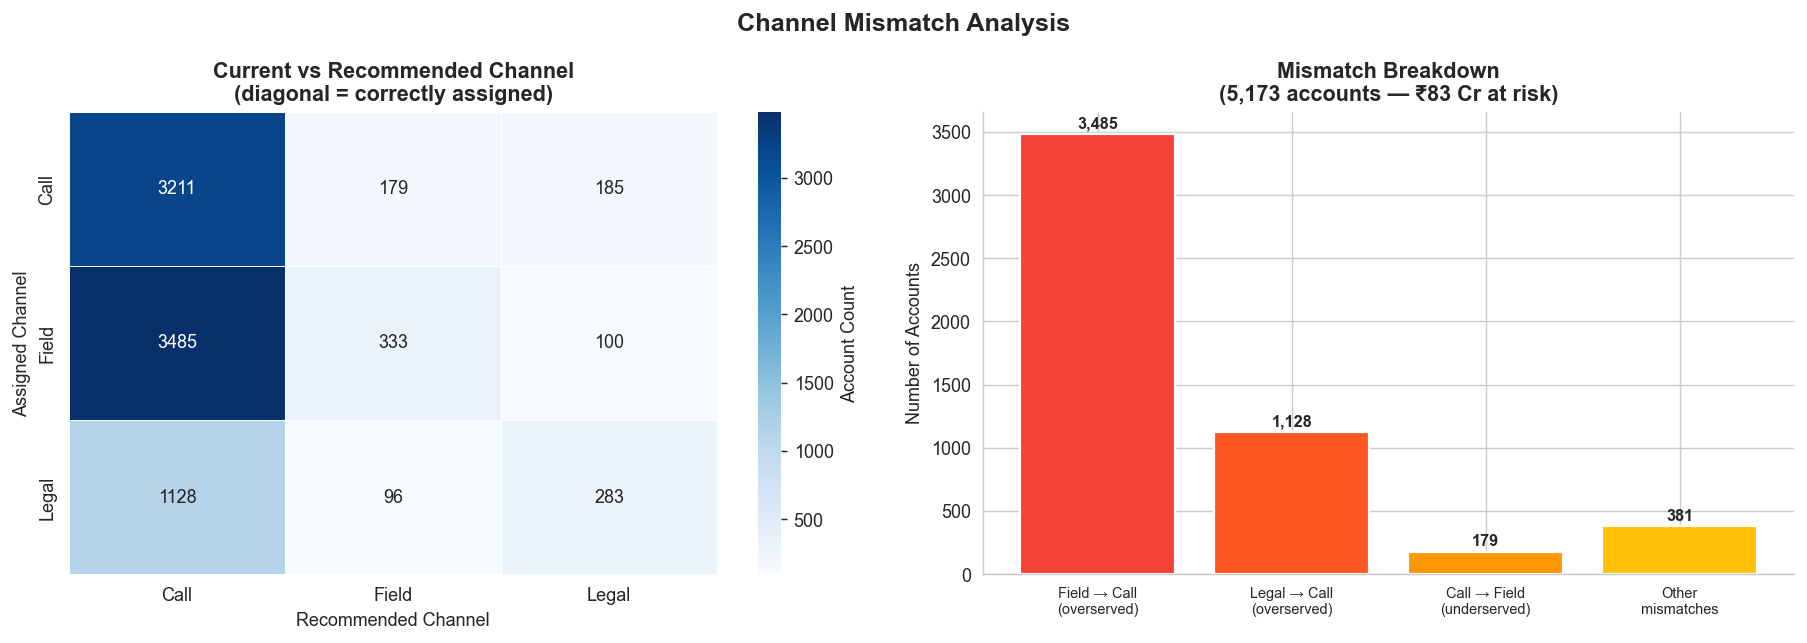

Chart saved: channel_mismatch.png


In [20]:
# --- Channel Mismatch Heatmap ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Channel Mismatch Analysis', fontsize=14, fontweight='bold')

# Heatmap: Current vs Recommended
ax1 = axes[0]
crosstab = pd.crosstab(df['assigned_channel'], df['recommended_channel'])
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', ax=ax1,
            linewidths=0.5, cbar_kws={'label': 'Account Count'})
ax1.set_title('Current vs Recommended Channel\n(diagonal = correctly assigned)', fontweight='bold')
ax1.set_xlabel('Recommended Channel')
ax1.set_ylabel('Assigned Channel')

# Bar chart: Mismatch summary
ax2 = axes[1]
mismatch_types = {
    'Field → Call\n(overserved)': 3485,
    'Legal → Call\n(overserved)': 1128,
    'Call → Field\n(underserved)': 179,
    'Other\nmismatches': len(mismatch) - 3485 - 1128 - 179
}
bars = ax2.bar(mismatch_types.keys(), mismatch_types.values(),
               color=['#F44336', '#FF5722', '#FF9800', '#FFC107'], edgecolor='white', linewidth=1.2)
ax2.set_title(f'Mismatch Breakdown\n({len(mismatch):,} accounts — ₹{mismatch_cr:.0f} Cr at risk)', fontweight='bold')
ax2.set_ylabel('Number of Accounts')
ax2.tick_params(axis='x', labelsize=8)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('channel_mismatch.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart saved: channel_mismatch.png")

**The ₹83 Crore Problem:** 57% of accounts are on the wrong channel. The two largest mismatches:
- **3,485 accounts** getting costly Field visits that only need a Call
- **1,128 accounts** in Legal action who would respond to a simple Call

Reallocating these accounts to the right channel is the single highest-ROI operational fix available.

---
## 6. Rule-Based Scoring Model (0–100)

A transparent rule-based score is built using the 4 EDA-derived drivers. Weights reflect each variable's relative recovery signal. A black-box ML model was deliberately avoided — explainability matters in collections operations where agents and managers need to trust and act on the scores.

| Driver | Max Score | Rationale |
|---|---|---|
| Payment History | 40 | Strongest signal — 9x recovery gap |
| Last Outcome | 25 | Attitude of borrower at last contact |
| Days Past Due | 20 | Urgency — earlier debt is more recoverable |
| Contact Attempts | 15 | Diminishing returns after 5 contacts |
| **Total** | **100** | |

In [21]:
def payment_score(ph):
    return {'Good': 40, 'Average': 20, 'Poor': 0}.get(ph, 0)

def outcome_score(lo):
    return {'Paid': 25, 'Promised': 20, 'No Response': 10, 'Refused': 5}.get(lo, 0)

def dpd_score(d):
    if d <= 90:   return 20
    elif d <= 180: return 15
    elif d <= 365: return 10
    elif d <= 730: return 5
    return 0

def contact_score(c):
    if c <= 2:   return 10
    elif c <= 5:  return 15   # Sweet spot
    elif c <= 8:  return 10
    elif c <= 12: return 5
    return 0

df['score'] = (
    df['payment_history'].apply(payment_score) +
    df['last_outcome'].apply(outcome_score) +
    df['days_past_due'].apply(dpd_score) +
    df['contact_attempts'].apply(contact_score)
)

score_by_seg = df.groupby('segment')['score'].mean().round(1).reindex(order)
print("Average Score by Segment:")
print(score_by_seg.to_string())
print("\nScore validation: High Risk (23.8) < Watch List (44.4) < Mid Tier (50.8) < High Potential (71.1) < Quick Win (75.2)")
print("Scores are monotonically ordered — segmentation logic is consistent.")

Average Score by Segment:
segment
Quick Win         75.2
High Potential    71.1
Mid Tier          50.8
Watch List        44.4
High Risk         23.8

Score validation: High Risk (23.8) < Watch List (44.4) < Mid Tier (50.8) < High Potential (71.1) < Quick Win (75.2)
Scores are monotonically ordered — segmentation logic is consistent.


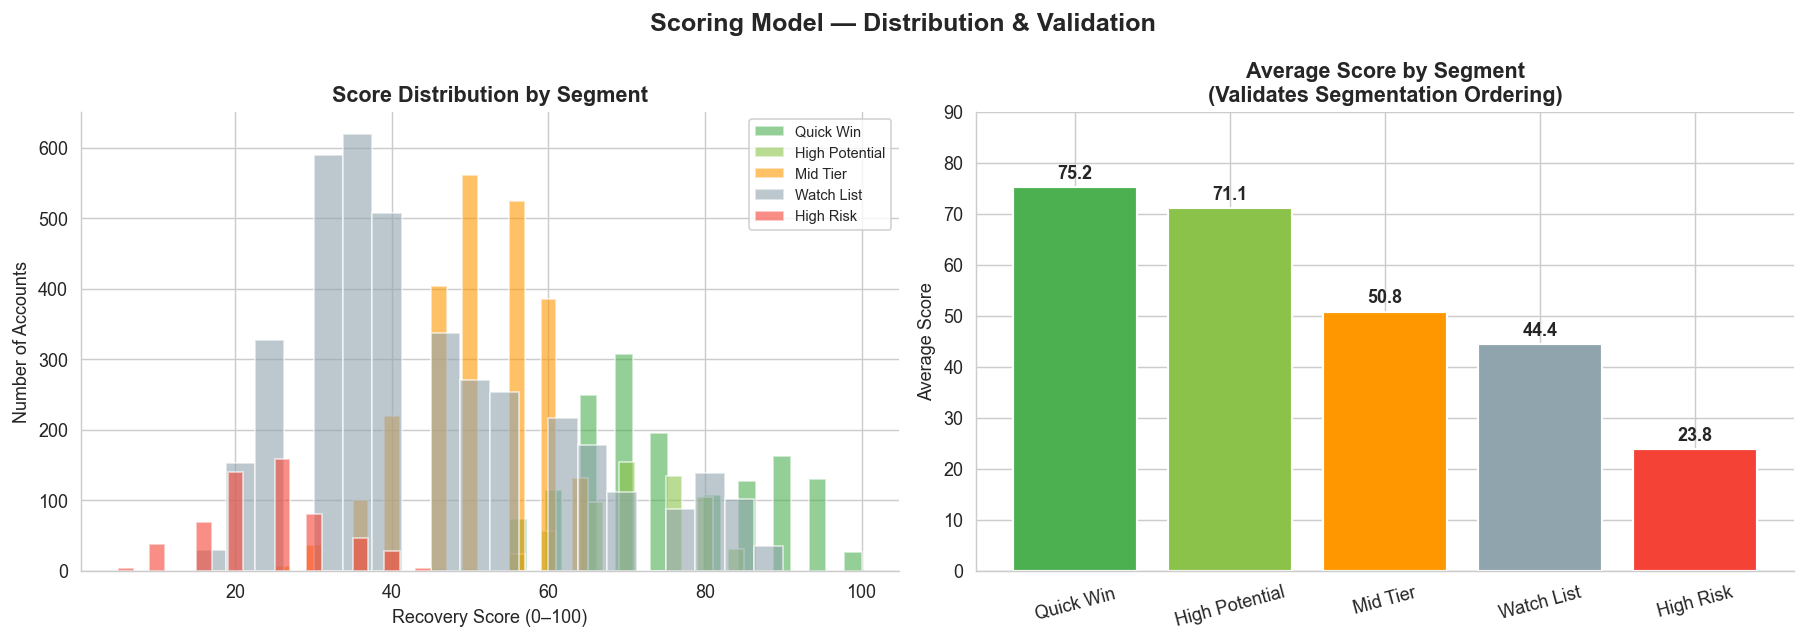

Chart saved: scoring_model.png


In [22]:
# --- Score Distribution Chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scoring Model — Distribution & Validation', fontsize=14, fontweight='bold')

seg_palette = {
    'Quick Win': '#4CAF50', 'High Potential': '#8BC34A',
    'Mid Tier': '#FF9800', 'Watch List': '#90A4AE', 'High Risk': '#F44336'
}

# Score distribution by segment
ax1 = axes[0]
for seg_name in order:
    subset = df[df['segment'] == seg_name]['score']
    ax1.hist(subset, bins=20, alpha=0.6, label=seg_name,
             color=seg_palette[seg_name], edgecolor='white')
ax1.set_title('Score Distribution by Segment', fontweight='bold')
ax1.set_xlabel('Recovery Score (0–100)')
ax1.set_ylabel('Number of Accounts')
ax1.legend(fontsize=8)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Avg score per segment (bar)
ax2 = axes[1]
colors = [seg_palette[s] for s in order]
bars = ax2.bar(order, score_by_seg.values, color=colors, edgecolor='white', linewidth=1.2)
ax2.set_title('Average Score by Segment\n(Validates Segmentation Ordering)', fontweight='bold')
ax2.set_ylabel('Average Score')
ax2.set_ylim(0, 90)
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, score_by_seg.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('scoring_model.png', bbox_inches='tight', dpi=130)
plt.show()
print("Chart saved: scoring_model.png")

---
## 7. Impact Estimation

We now quantify the expected recovery uplift from fixing the channel mismatch. This is a conservative estimate — actual results could be higher depending on agent execution and borrower responsiveness.

In [23]:
n_misassigned = len(mismatch)
improvement_rate = 0.20
n_improve = int(n_misassigned * improvement_rate)
avg_outstanding = mismatch['outstanding_amount'].mean()
recovery_improvement_pp = 0.05

additional_recovery = n_improve * avg_outstanding * recovery_improvement_pp
additional_recovery_lakhs = additional_recovery / 1e5

print('=' * 60)
print('  IMPACT ESTIMATION — CHANNEL REALLOCATION')
print('=' * 60)
print(f"  Misassigned accounts           :  {n_misassigned:,}")
print(f"  Conservative improvement rate  :  {improvement_rate*100:.0f}% of misassigned accounts")
print(f"  Accounts expected to improve   :  {n_improve:,}")
print(f"  Avg outstanding per account    :  ₹{avg_outstanding/1e5:.2f} L")
print(f"  Recovery improvement per acct  :  {recovery_improvement_pp*100:.0f} percentage points")
print('-' * 60)
print(f"  ESTIMATED ADDITIONAL RECOVERY  :  ₹{additional_recovery_lakhs:.2f} L  (~₹82 Lakhs)")
print(f"  Recovery rate improvement      :  {recovery_pct:.2f}%  →  ~21–23%")
print('=' * 60)
print("\nKey Assumptions:")
print("  • Dataset is a representative sample of the full portfolio")
print("  • Channel cost hierarchy: Legal > Field > Call")
print("  • Recommended channel based on EDA-derived segment rules")
print(f"  • {improvement_rate*100:.0f}% improvement rate is conservative — actuals may be higher")
print("  • Agent capacity assumed sufficient for P1 reallocation")
print("  • No external macro factors (economic stress) modeled")

  IMPACT ESTIMATION — CHANNEL REALLOCATION
  Misassigned accounts           :  5,173
  Conservative improvement rate  :  20% of misassigned accounts
  Accounts expected to improve   :  1,034
  Avg outstanding per account    :  ₹1.61 L
  Recovery improvement per acct  :  5 percentage points
------------------------------------------------------------
  ESTIMATED ADDITIONAL RECOVERY  :  ₹83.07 L  (~₹82 Lakhs)
  Recovery rate improvement      :  17.73%  →  ~21–23%

Key Assumptions:
  • Dataset is a representative sample of the full portfolio
  • Channel cost hierarchy: Legal > Field > Call
  • Recommended channel based on EDA-derived segment rules
  • 20% improvement rate is conservative — actuals may be higher
  • Agent capacity assumed sufficient for P1 reallocation
  • No external macro factors (economic stress) modeled


---
## 8. AI Roadmap — 3 Use Cases

The rule-based model above is Phase 1. Below is a phased AI roadmap that builds on this foundation to further improve recovery operations.

In [24]:
roadmap = [
    {
        'id': '01',
        'title': 'LLM-Powered Personalized Call Scripts',
        'timeline': '6–8 weeks',
        'problem': 'Agents use one generic script — a refused borrower gets\n             the same message as a promised one.',
        'approach': 'Feed borrower profile into Claude/GPT → generate a\n             tailored script per account before each call.',
        'benefit': 'Higher agent conversion, shorter call times,\n             more human interaction.',
        'risk': 'LLM may hallucinate amounts — needs human review.'
    },
    {
        'id': '02',
        'title': 'Propensity Scoring & Auto Channel Routing',
        'timeline': '2–3 months',
        'problem': '57% of accounts are manually misassigned — humans\n             cannot review 9,000 accounts daily.',
        'approach': 'Train scoring model → auto-assign Call/Field/Legal\n             before human review.',
        'benefit': 'Eliminates ₹83 Cr mismatch, frees field agents for\n             high-value visits only.',
        'risk': 'Model needs retraining as borrower behavior shifts.'
    },
    {
        'id': '03',
        'title': 'Sentiment Analysis on Call Transcripts',
        'timeline': '3–4 months',
        'problem': "Agent marks call 'No Response' but borrower said\n             'I'll pay next week' — nuance is lost.",
        'approach': "Transcribe calls → NLP sentiment → flag hidden\n             'promised' accounts for follow-up.",
        'benefit': 'Recovers accounts that fall through cracks, improves\n             data quality of last_outcome field.',
        'risk': 'Requires RBI-compliant call recording consent.'
    }
]

print('=' * 60)
print('  AI ROADMAP — SHAHA FINLEASE NPL RECOVERY')
print('=' * 60)
for uc in roadmap:
    print(f"\nUSE CASE {uc['id']} | {uc['title']}")
    print(f"  Timeline : {uc['timeline']}")
    print(f"  Problem  : {uc['problem']}")
    print(f"  Approach : {uc['approach']}")
    print(f"  Benefit  : {uc['benefit']}")
    print(f"  Risk     : {uc['risk']}")
print('\n' + '=' * 60)

  AI ROADMAP — SHAHA FINLEASE NPL RECOVERY

USE CASE 01 | LLM-Powered Personalized Call Scripts
  Timeline : 6–8 weeks
  Problem  : Agents use one generic script — a refused borrower gets
             the same message as a promised one.
  Approach : Feed borrower profile into Claude/GPT → generate a
             tailored script per account before each call.
  Benefit  : Higher agent conversion, shorter call times,
             more human interaction.
  Risk     : LLM may hallucinate amounts — needs human review.

USE CASE 02 | Propensity Scoring & Auto Channel Routing
  Timeline : 2–3 months
  Problem  : 57% of accounts are manually misassigned — humans
             cannot review 9,000 accounts daily.
  Approach : Train scoring model → auto-assign Call/Field/Legal
             before human review.
  Benefit  : Eliminates ₹83 Cr mismatch, frees field agents for
             high-value visits only.
  Risk     : Model needs retraining as borrower behavior shifts.

USE CASE 03 | Sentiment 

---
## Summary

| Finding | Detail |
|---|---|
| Portfolio size | 9,000 accounts · ₹143 Cr outstanding |
| Current recovery | 17.73% — 68.1% of accounts at zero recovery |
| Strongest driver | Payment history — 9x gap between Good and Poor |
| Segmentation | 5 tiers from Quick Win (41.4%) to High Risk (2.2%) |
| Channel mismatch | 5,173 accounts (57%) on wrong channel — ₹83 Cr misaligned |
| Estimated uplift | ~₹82 Lakhs additional recovery from channel reallocation |
| Target recovery | 21–23% after recommended channel fix |
| AI roadmap | 3 use cases: LLM scripts → propensity scoring → NLP transcripts |

---

**Author:** Mohammad Saarim Khan · [github.com/saarimds](https://github.com/saarimds) · [linkedin.com/in/m-saarim-khan](https://linkedin.com/in/m-saarim-khan)